In [ ]:
import os 
import pandas as pd 
import numpy as np

from dotenv import load_dotenv

import requests 
import json 

from bs4 import BeautifulSoup
import io

import csv

import time

import geopandas as gpd

import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import folium # for map
import contextily as ctx
from shapely.geometry import LineString


In [ ]:
#### setting dictionaries - mappings 


[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/30.1 MB ? eta -:--:--
    --------------------------------------- 0.5/30.1 MB 2.8 MB/s eta 0:00:11
   - -------------------------------------- 1.3/30.1 MB 3.4 MB/s eta 0:00:09
   -- ------------------------------------- 2.1/30.1 MB 3.8 MB/s eta 0:00:08
   --- ------------------------------------ 2.9/30.1 MB 3.7 MB/s eta 0:00:08
   ---- ----------------------------------- 3.7/30.1 MB 3.7 MB/s eta 0:00:08
   ----- ---------------------------------- 4.5/30.1 MB 3.7 MB/s eta 0:00:07
   ------ --------------------------------- 5.2/30.1 MB 3.7 MB/s eta 0:00:07
   ------- -------------------------------- 5.8/30.1 MB 3.6 MB/s eta 0:00:07
   -------- ------------------------------- 6.6/30.1 MB 3.6 MB/s eta 0:00:07
   --------- ------------------------------ 7.1/30.1 MB 3.5 MB/s eta 0:00:07
   ---------- ----------------------------- 8.1/30.1 MB 3.6 MB/s eta 0:00:07
   ----------- ---------------------------- 8.9/30.1 MB 3.6 MB/s eta 0:00:06
   ---

In [2]:
import os
proj_root = os.path.abspath(os.path.join(os.getcwd(), ".."))   # notebooks/ -> project root
data_dir = os.path.join(proj_root, "data", "raw")
os.makedirs(data_dir, exist_ok=True)

In [3]:
import os, sys
print(data_dir)
print("cwd:", os.getcwd())
print("src exists:", os.path.exists(os.path.join(os.getcwd(), "src")))
print("sys.path[0]:", sys.path[0])

c:\Users\marki\Data-Processing-in-Python---Project\data\raw
cwd: c:\Users\marki\Data-Processing-in-Python---Project\notebooks
src exists: False
sys.path[0]: c:\Users\marki\AppData\Local\Programs\Python\Python313\python313.zip


In [4]:
### chmi weather stations - data processing

df_chmi_stat = pd.read_csv(os.path.join(data_dir, "chmi_weather_stations_metadata.csv"))

df_chmi_stat = df_chmi_stat[df_chmi_stat['FULL_NAME'].str.contains('Praha', case=False, na=False)]

wsi_to_drop = [
    '0-203-0-11201020001', #Praha, Vinohrady - Flora	
    '0-203-0-11202007001', #Praha, Suchdol
    '0-203-0-11105048001', #Praha, Zadní Kopanina
    '0-203-0-11201020003' #Praha, Chodov
    ]

df_chmi_stat = df_chmi_stat[~df_chmi_stat['WSI'].isin(wsi_to_drop)]

df_chmi_stat["END_DATE_DT"] = pd.to_datetime(df_chmi_stat["END_DATE"], utc=True, errors="coerce")

df_chmi_stat = (
    df_chmi_stat.sort_values("END_DATE_DT")
    .drop_duplicates(subset="WSI", keep="last")
)

now_utc = pd.Timestamp.now(tz="UTC")
df_chmi_stat = df_chmi_stat[
    (df_chmi_stat["END_DATE_DT"] >= now_utc)
]

In [6]:
df_chmi_stat

,WSI,GH_ID,BEGIN_DATE,END_DATE,FULL_NAME,GEOGR1,GEOGR2,ELEVATION,END_DATE_DT
1101,0-203-0-10904013001,P1PKOM01,2017-12-07T12:00:00Z,3999-12-31T23:59:00Z,"Praha, Komořany",14.406360,49.988600,213.00,3999-12-31 23:59:00+00:00
75,0-20000-0-11567,P1PKBE01,2010-10-01T00:00:00Z,3999-12-31T23:59:00Z,"Praha, Kbely",14.538056,50.123333,284.50,3999-12-31 23:59:00+00:00
1429,0-203-0-11201024001,P1PBRE01,2013-09-01T00:00:00Z,3999-12-31T23:59:00Z,"Praha, Břevnov",14.352689,50.080843,355.00,3999-12-31 23:59:00+00:00
68,0-20000-0-11520,P1PLIB01,2018-05-17T00:00:00Z,3999-12-31T23:59:00Z,"Praha, Libuš",14.446944,50.007778,302.04,3999-12-31 23:59:00+00:00
65,0-20000-0-11519,P1PKAR01,2024-09-01T00:00:00Z,3999-12-31T23:59:00Z,"Praha, Karlov",14.427778,50.069167,260.50,3999-12-31 23:59:00+00:00
2214,0-203-0-11514,P1PKLE01,2023-01-01T00:00:00Z,3999-12-31T23:59:00Z,"Praha, Klementinum",14.416923,50.086634,190.70,3999-12-31 23:59:00+00:00
62,0-20000-0-11518,P1PRUZ01,2000-01-01T00:00:00Z,3999-12-31T23:59:00Z,"Praha, Ruzyně",14.255556,50.100278,364.00,3999-12-31 23:59:00+00:00
2217,0-203-0-11515,P1PKLM01,2023-01-01T00:00:00Z,3999-12-31T23:59:00Z,"Praha, Klementinum",14.416436,50.086341,190.70,3999-12-31 23:59:00+00:00
1273,0-203-0-11101007001,L4PRAH01,2015-03-01T00:00:00Z,3999-12-31T23:59:00Z,"Praha, Brdy",13.818380,49.658890,862.00,3999-12-31 23:59:00+00:00


In [5]:
### discionary of wsi codes

wsi_dict = dict(
    zip(
        df_chmi_stat["WSI"].astype(str),
        df_chmi_stat["FULL_NAME"].astype(str)  
    )
)

with open(os.path.join(data_dir, "wsi_dict.csv"),"w",encoding="utf-8-sig",newline="") as f:
    writer=csv.writer(f); writer.writerow(["key","value"]); writer.writerows(wsi_dict.items())

In [6]:
### chmi weather variables

### filtering only needed ones

df_chmi_vars = pd.read_csv(os.path.join(data_dir, "chmi_weather_variables_metadata.csv"))

df_chmi_vars = df_chmi_vars[df_chmi_vars['WSI'].astype(str).isin(wsi_dict)]

### dictionary of variables abbreviations and names
chmi_vars_dict = dict(
    zip(
        df_chmi_vars['EG_EL_ABBREVIATION'].astype(str),
        df_chmi_vars['NAME'].astype(str)  
    )
)

with open(os.path.join(data_dir, "chmi_vars_dict.csv"),"w",encoding="utf-8-sig",newline="") as f:
    writer=csv.writer(f); writer.writerow(["key","value"]); writer.writerows(chmi_vars_dict.items())

In [107]:
### chmi weather 10min data

df_weather_10min = pd.read_csv(os.path.join(data_dir, "weather_data_10min.csv"))

# it gives flag warning, but i assume flag is not of interest


KeyboardInterrupt: 

In [7]:
### chmi weather 1h data

df_weather = pd.read_csv(os.path.join(data_dir, "weather_data_10min_hourly.csv"))



C:\Users\marki\AppData\Local\Temp\ipykernel_3728\1235324710.py:3: DtypeWarning: Columns (0: FLAG) have mixed types. Specify dtype option on import or set low_memory=False.
  df_weather = pd.read_csv(os.path.join(data_dir, "weather_data_10min_hourly.csv"))


In [8]:
df_weather.head()

,STATION,ELEMENT,DT,VAL,FLAG,QUALITY,WSI,YEAR,MONTH
0,0-203-0-10904013001,H,2025-11-01 00:00:00+00:00,96.0,NaN,0.0,0-203-0-10904013001,2025,11
1,0-203-0-10904013001,H,2025-11-01 01:00:00+00:00,96.0,NaN,0.0,0-203-0-10904013001,2025,11
2,0-203-0-10904013001,H,2025-11-01 02:00:00+00:00,96.0,NaN,0.0,0-203-0-10904013001,2025,11
3,0-203-0-10904013001,H,2025-11-01 03:00:00+00:00,96.0,NaN,0.0,0-203-0-10904013001,2025,11
4,0-203-0-10904013001,H,2025-11-01 04:00:00+00:00,96.0,NaN,0.0,0-203-0-10904013001,2025,11


In [9]:
df_weather['FLAG'].isna().sum()

np.int64(69031)

In [10]:
df_weather['FLAG'].notna().sum()

np.int64(84)

In [11]:
df_weather['FLAG'].unique()

<StringArray>
[nan, 'Z']
Length: 2, dtype: str

In [12]:
df_weather['QUALITY'].unique()

array([0., 4., 3.])

In [13]:
### mapping variables names in weather data 
df_weather['ELEMENT_NAME'] = df_weather['ELEMENT'].map(chmi_vars_dict)

df_weather['WSI_NAME'] = df_weather['WSI'].map(wsi_dict)


In [14]:
df_weather

,STATION,ELEMENT,DT,VAL,FLAG,QUALITY,WSI,YEAR,MONTH,ELEMENT_NAME,WSI_NAME
0,0-203-0-10904013001,H,2025-11-01 00:00:00+00:00,96.0,NaN,0.0,0-203-0-10904013001,2025,11,Vlhkost relat,"Praha, Komořany"
1,0-203-0-10904013001,H,2025-11-01 01:00:00+00:00,96.0,NaN,0.0,0-203-0-10904013001,2025,11,Vlhkost relat,"Praha, Komořany"
2,0-203-0-10904013001,H,2025-11-01 02:00:00+00:00,96.0,NaN,0.0,0-203-0-10904013001,2025,11,Vlhkost relat,"Praha, Komořany"
3,0-203-0-10904013001,H,2025-11-01 03:00:00+00:00,96.0,NaN,0.0,0-203-0-10904013001,2025,11,Vlhkost relat,"Praha, Komořany"
4,0-203-0-10904013001,H,2025-11-01 04:00:00+00:00,96.0,NaN,0.0,0-203-0-10904013001,2025,11,Vlhkost relat,"Praha, Komořany"
...,...,...,...,...,...,...,...,...,...,...,...
69110,0-203-0-11101007001,T,2025-11-30 19:00:00+00:00,2.3,NaN,0.0,0-203-0-11101007001,2025,11,Teplota,"Praha, Brdy"
69111,0-203-0-11101007001,T,2025-11-30 20:00:00+00:00,2.6,NaN,0.0,0-203-0-11101007001,2025,11,Teplota,"Praha, Brdy"
69112,0-203-0-11101007001,T,2025-11-30 21:00:00+00:00,2.2,NaN,0.0,0-203-0-11101007001,2025,11,Teplota,"Praha, Brdy"
69113,0-203-0-11101007001,T,2025-11-30 22:00:00+00:00,1.2,NaN,0.0,0-203-0-11101007001,2025,11,Teplota,"Praha, Brdy"


In [15]:
### add metadata about stations

stations_meta = pd.read_csv(os.path.join(data_dir, "chmi_weather_stations_metadata.csv"))

In [16]:
stations_meta = stations_meta[stations_meta['WSI'].isin(wsi_dict)]

stations_meta["END_DATE_DT"] = pd.to_datetime(stations_meta["END_DATE"], utc=True, errors="coerce")

stations_meta = (
    stations_meta.sort_values("END_DATE_DT")
    .drop_duplicates(subset="WSI", keep="last")
)

now_utc = pd.Timestamp.now(tz="UTC")
df_chmi_stat = df_chmi_stat[
    (df_chmi_stat["END_DATE_DT"] >= now_utc)
]

In [17]:
stations_sel = stations_meta[["WSI", "FULL_NAME", "ELEVATION", "GEOGR1", "GEOGR2"]].copy()
stations_sel = stations_sel.rename(columns={
    "GEOGR1": "LON",
    "GEOGR2": "LAT"
})

df_weather["WSI"] = df_weather["WSI"].astype(str)
stations_sel["WSI"] = stations_sel["WSI"].astype(str)

In [18]:
df_weather_ext = df_weather.merge(stations_sel, on="WSI", how="left")


In [24]:
print((df_weather_ext["FULL_NAME"] != df_weather_ext["WSI_NAME"]).any())
print((df_weather_ext["WSI"] != df_weather_ext["STATION"]).any())

False
False


In [116]:
### air quality chmi data

In [19]:
air_stations_meta = pd.read_csv(os.path.join(data_dir, "airquality_CHMI_stations_metadata.csv"))

In [20]:
air_stations_meta = air_stations_meta[air_stations_meta['locality_name'].str.contains('Praha', case=False, na=False)]


In [28]:
air_stations_meta

,id_registration,station_code,locality_code,locality_name,street,city,lon,lat,alt,component_code,component_name,unit
39,783575,AREPA,AREP,Praha 1-n. Republiky,NaN,NaN,14.429220,50.088066,190 m,NO2,oxid dusičitý,ug/m^3
40,783579,AREPA,AREP,Praha 1-n. Republiky,NaN,NaN,14.429220,50.088066,190 m,NOx,oxidy dusíku,ug/m^3
41,783591,AREPA,AREP,Praha 1-n. Republiky,NaN,NaN,14.429220,50.088066,190 m,PM10,částice PM10,ug/m^3
42,1648334,AREPA,AREP,Praha 1-n. Republiky,NaN,NaN,14.429220,50.088066,190 m,INDX,Index kvality ovzduší,NaN
66,41157,ALEGA,ALEG,Praha 2-Legerova (hot spot),Legerov 1843,Praha 2,14.430673,50.072388,219 m,NO2,oxid dusičitý,ug/m^3
...,...,...,...,...,...,...,...,...,...,...,...,...
436,1648433,ABREA,ABRE,Praha 6-Břevnov,Šlikova,Praha 6,14.380116,50.084385,300 m,INDX,Index kvality ovzduší,NaN
480,1410468,ACHOA,ACHO,Praha 4-Chodov,Vejvanovského,Praha 4,14.517450,50.030170,300 m,NO2,oxid dusičitý,ug/m^3
481,1410474,ACHOA,ACHO,Praha 4-Chodov,Vejvanovského,Praha 4,14.517450,50.030170,300 m,NOx,oxidy dusíku,ug/m^3
482,1410479,ACHOA,ACHO,Praha 4-Chodov,Vejvanovského,Praha 4,14.517450,50.030170,300 m,PM10,částice PM10,ug/m^3


In [ ]:
### this is only for one import file, i.e. one day

# df_air_qual = pd.read_csv(os.path.join(data_dir, "airquality_CHMI_stations_data.csv"))

In [21]:
df_air_qual = pd.read_csv(os.path.join(data_dir, "airquality_CHMI_1hour.csv"))

In [22]:
df_air_qual

,idRegistration,startTime,idValueType,value,source_file
0,10221,2025-11-01T00:00:00Z,8,1.3,airquality_1h_avg_CZ_2025110100.csv
1,40237,2025-11-01T00:00:00Z,8,48.7,airquality_1h_avg_CZ_2025110100.csv
2,40238,2025-11-01T00:00:00Z,8,6.2,airquality_1h_avg_CZ_2025110100.csv
3,40244,2025-11-01T00:00:00Z,8,12.6,airquality_1h_avg_CZ_2025110100.csv
4,40257,2025-11-01T00:00:00Z,6,-5009.0,airquality_1h_avg_CZ_2025110100.csv
...,...,...,...,...,...
345776,2053564,2025-11-30T23:00:00Z,6,-5009.0,airquality_1h_avg_CZ_2025113023.csv
345777,2140455,2025-11-30T23:00:00Z,6,-5009.0,airquality_1h_avg_CZ_2025113023.csv
345778,2140459,2025-11-30T23:00:00Z,6,-5009.0,airquality_1h_avg_CZ_2025113023.csv
345779,2140463,2025-11-30T23:00:00Z,6,-5009.0,airquality_1h_avg_CZ_2025113023.csv


In [23]:
### match with metadata based on idregistration

df_air_qual = df_air_qual.rename(columns={
    "idRegistration": "id_registration"
}
)

df_air_qual["id_registration"] = df_air_qual["id_registration"].astype(str)
air_stations_meta["id_registration"] = air_stations_meta["id_registration"].astype(str)

In [24]:
# join

df_air_qual = df_air_qual.merge(air_stations_meta, on="id_registration", how="right")

In [25]:
df_air_qual

,id_registration,startTime,idValueType,value,source_file,station_code,locality_code,locality_name,street,city,lon,lat,alt,component_code,component_name,unit
0,783575,2025-11-01T00:00:00Z,8,42.1,airquality_1h_avg_CZ_2025110100.csv,AREPA,AREP,Praha 1-n. Republiky,NaN,NaN,14.42922,50.088066,190 m,NO2,oxid dusičitý,ug/m^3
1,783575,2025-11-01T01:00:00Z,8,36.0,airquality_1h_avg_CZ_2025110101.csv,AREPA,AREP,Praha 1-n. Republiky,NaN,NaN,14.42922,50.088066,190 m,NO2,oxid dusičitý,ug/m^3
2,783575,2025-11-01T02:00:00Z,8,36.2,airquality_1h_avg_CZ_2025110102.csv,AREPA,AREP,Praha 1-n. Republiky,NaN,NaN,14.42922,50.088066,190 m,NO2,oxid dusičitý,ug/m^3
3,783575,2025-11-01T03:00:00Z,8,28.3,airquality_1h_avg_CZ_2025110103.csv,AREPA,AREP,Praha 1-n. Republiky,NaN,NaN,14.42922,50.088066,190 m,NO2,oxid dusičitý,ug/m^3
4,783575,2025-11-01T04:00:00Z,8,26.6,airquality_1h_avg_CZ_2025110104.csv,AREPA,AREP,Praha 1-n. Republiky,NaN,NaN,14.42922,50.088066,190 m,NO2,oxid dusičitý,ug/m^3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47417,1648733,2025-11-30T19:00:00Z,148,1.0,airquality_1h_avg_CZ_2025113019.csv,ACHOA,ACHO,Praha 4-Chodov,Vejvanovského,Praha 4,14.51745,50.030170,300 m,INDX,Index kvality ovzduší,NaN
47418,1648733,2025-11-30T20:00:00Z,148,1.0,airquality_1h_avg_CZ_2025113020.csv,ACHOA,ACHO,Praha 4-Chodov,Vejvanovského,Praha 4,14.51745,50.030170,300 m,INDX,Index kvality ovzduší,NaN
47419,1648733,2025-11-30T21:00:00Z,148,1.0,airquality_1h_avg_CZ_2025113021.csv,ACHOA,ACHO,Praha 4-Chodov,Vejvanovského,Praha 4,14.51745,50.030170,300 m,INDX,Index kvality ovzduší,NaN
47420,1648733,2025-11-30T22:00:00Z,148,1.0,airquality_1h_avg_CZ_2025113022.csv,ACHOA,ACHO,Praha 4-Chodov,Vejvanovského,Praha 4,14.51745,50.030170,300 m,INDX,Index kvality ovzduší,NaN


In [ ]:
### golemio air quality 

#### air quality metadata processing

# station_cols = {
#     'geometry.coordinates': 'coordinates', 
#     'properties.id': 'id', 
#     'properties.name': 'name', 
#     'properties.district': 'district', 
#     'properties.measurement.components.type': 'components'
# }

# air_quality_stations = df[station_cols.keys()]

# air_quality_stations = air_quality_stations.rename(columns=station_cols)

# air_quality_stations = (
#     air_quality_stations.groupby('id', as_index=False)
#     .agg({
#         'coordinates': 'first',
#         'name': 'first',
#         'district': 'first',
#         'components': list
#     })
# )

# air_quality_stations[["lon", "lat"]] = pd.DataFrame(air_quality_stations["coordinates"].tolist(), index=air_quality_stations.index)
# air_quality_stations["lon"] = pd.to_numeric(air_quality_stations["lon"], errors="coerce")
# air_quality_stations["lat"] = pd.to_numeric(air_quality_stations["lat"], errors="coerce")


In [ ]:

#air quality stations dictionary

# air_stat_dict = dict(
#     zip(
#         air_quality_stations['id'].astype(str),
#         air_quality_stations['name'].astype(str)  
#     )
# )

In [26]:
### loading the dictionaries


def load_wsi_dict(path="data/raw/wsi_dict.csv"):
    df = pd.read_csv(path, dtype=str)
    return dict(df.values)

def load_chmi_vars(path="data/raw/chmi_vars.json"):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

In [27]:
# list unique measured weather variables
df_weather_ext[["ELEMENT", "ELEMENT_NAME"]].drop_duplicates().sort_values("ELEMENT")



,ELEMENT,ELEMENT_NAME
4320,Casmax,Čas maxima
5040,D,Směr větru
5760,Dmax,Směr Fmax
6480,Dprum,Směr větru prům
7200,F,Rychlost větru
7920,Fmax,Max rychlost
8640,Fprum,Rychlost prům
0,H,Vlhkost relat
10080,P,Tlak vzduchu
25919,RGLB10,Záření globální


In [28]:
# list all unique pollutants
df_air_qual[["component_code", "component_name", "unit"]].drop_duplicates()

,component_code,component_name,unit
0,NO2,oxid dusičitý,ug/m^3
719,NOx,oxidy dusíku,ug/m^3
1438,PM10,částice PM10,ug/m^3
2157,INDX,Index kvality ovzduší,NaN
4304,CO,oxid uhelnatý,ug/m^3
5018,PM2_5,"jemné částice PM2,5",ug/m^3
11479,O3,přízemní ozon,ug/m^3
13636,SO2,oxid siřičitý,ug/m^3


### Connect stations by their distance

In [124]:
# install if needed
#pip install geopandas folium mapclassify

In [29]:
# list all weather and air quality stations ----
weather_stations = (
    stations_meta
    .loc[:, ["WSI", "FULL_NAME", "GEOGR1", "GEOGR2", "ELEVATION"]]
    .drop_duplicates()
    .rename(columns={
        "WSI": "weather_station_id",
        "FULL_NAME": "weather_station_name",
        "GEOGR1": "weather_lon",
        "GEOGR2": "weather_lat",
        "ELEVATION": "weather_alt"
    })
)

air_stations = (
    air_stations_meta
    .loc[
        air_stations_meta["locality_name"].str.contains("Praha", case=False, na=False),
        ["station_code", "locality_name", "lon", "lat", "alt"]
    ]
    .drop_duplicates()
    .rename(columns={
        "station_code": "air_station_code",
        "locality_name": "air_station_name",
        "lon": "air_lon",
        "lat": "air_lat",
        "alt": "air_alt"
    })
)


In [30]:
# match stations ----
# convert both station lists to geopandas dataframes
air_gdf = gpd.GeoDataFrame(
    air_stations,
    geometry=gpd.points_from_xy(
        air_stations["air_lon"],
        air_stations["air_lat"]
    ),
    crs="EPSG:4326"
)
weather_gdf = gpd.GeoDataFrame(
    weather_stations,
    geometry=gpd.points_from_xy(
        weather_stations["weather_lon"],
        weather_stations["weather_lat"]
    ),
    crs="EPSG:4326"
)
# convert to meters
air_gdf_m = air_gdf.to_crs("EPSG:5514")
weather_gdf_m = weather_gdf.to_crs("EPSG:5514")
# find nearest matches
nearest_match = gpd.sjoin_nearest(
    air_gdf_m,
    weather_gdf_m,
    how="left",
    distance_col="distance_m"
)
# add column for km
nearest_match["distance_km"] = nearest_match["distance_m"] / 1000
# clean cols
nearest_match = nearest_match[
    [
        "air_station_code",
        "air_station_name",
        "air_lon",
        "air_lat",
        "air_alt",
        "weather_station_id",
        "weather_station_name",
        "weather_lon",
        "weather_lat",
        "weather_alt",
        "distance_m",
        "distance_km"
    ]
].copy()
# print the matches by decreasing distance
nearest_match.sort_values("distance_km", ascending=False)[
    [
        "air_station_name",
        "weather_station_name",
        "distance_km"
    ]
]

,air_station_name,weather_station_name,distance_km
219,Praha 10-Průmyslová,"Praha, Kbely",6.788402
480,Praha 4-Chodov,"Praha, Libuš",5.632987
279,Praha 8-Kobylisy,"Praha, Kbely",5.041256
315,Praha 6-Suchdol,"Praha, Klementinum",5.002194
215,Praha 5-Stodůlky,"Praha, Břevnov",4.150278
248,Praha 7-Holešovice,"Praha, Klementinum",3.123899
76,Praha 9-Vysočany,"Praha, Kbely",2.847472
433,Praha 6-Břevnov,"Praha, Břevnov",2.002016
72,Praha 8-Karlín,"Praha, Klementinum",1.986876
413,Praha 2-Riegrovy sady,"Praha, Karlov",1.736525


In [ ]:
# now:
## some of weather stations not used
## two different Klementinum stations that are very close to each other
## weather stations get matched more than once
## some are quite far away

# alternatives:
## keep only close matches
## merge Klementinum into one station
## match each weather station exactly once

In [31]:
# Preprocess data before merging ----

# copies
air = df_air_qual.copy()
weather = df_weather_ext.copy()
station_match = nearest_match.copy()
# clean column names
air.columns = air.columns.str.strip()
weather.columns = weather.columns.str.strip()
station_match.columns = station_match.columns.str.strip()
# set time columns
air_time_col = "startTime"
weather_time_col = "DT"
# clean station names
air["locality_name"] = air["locality_name"].astype(str).str.strip()
weather["WSI_NAME"] = weather["WSI_NAME"].astype(str).str.strip()
station_match["air_station_name"] = station_match["air_station_name"].astype(str).str.strip()
station_match["weather_station_name"] = station_match["weather_station_name"].astype(str).str.strip()
# convert times
air[air_time_col] = pd.to_datetime(air[air_time_col]).dt.tz_localize(None)
weather[weather_time_col] = pd.to_datetime(weather[weather_time_col]).dt.tz_localize(None)
# keep one nearest weather station per air station
station_match_nearest = (
    station_match
    .sort_values("distance_m")
    .drop_duplicates(subset=["air_station_name"], keep="first")
    .copy()
)


In [32]:
# Pivot wider air ----
air_wide = (
    air
    .pivot_table(
        index=[air_time_col, "locality_name"],
        columns="component_code",
        values="value",
        aggfunc="mean"
    )
    .reset_index()
)
air_wide.columns.name = None
air_wide = air_wide.rename(
    columns={
        col: f"air_{col}"
        for col in air_wide.columns
        if col not in [air_time_col, "locality_name"]
    }
)
air_wide_with_match = air_wide.merge(
    station_match_nearest,
    left_on="locality_name",
    right_on="air_station_name",
    how="left",
    validate="many_to_one"
)
air_wide.head()


,startTime,locality_name,air_CO,air_INDX,air_NO2,air_NOx,air_O3,air_PM10,air_PM2_5,air_SO2
0,2025-11-01,Praha 1-n. Republiky,NaN,3.0,42.1,158.6,NaN,45.4,NaN,NaN
1,2025-11-01,Praha 10-Průmyslová,NaN,2.0,30.4,96.2,NaN,32.5,NaN,NaN
2,2025-11-01,Praha 10-Vršovice,NaN,3.0,32.7,201.4,NaN,54.9,NaN,NaN
3,2025-11-01,Praha 2-Legerova (hot spot),1051.0,3.0,42.3,191.7,NaN,49.2,40.6,NaN
4,2025-11-01,Praha 2-Riegrovy sady,NaN,3.0,-5009.0,-5009.0,-5009.0,-5009.0,-5009.0,-5009.0


In [33]:
# pivot wider weather ----
weather_wide = (
    weather
    .pivot_table(
        index=[weather_time_col, "WSI_NAME"],
        columns="ELEMENT",
        values="VAL",
        aggfunc="mean"
    )
    .reset_index()
)
weather_wide.columns.name = None
weather_wide = weather_wide.rename(
    columns={
        col: f"weather_{col}"
        for col in weather_wide.columns
        if col not in [weather_time_col, "WSI_NAME"]
    }
)

weather_wide.head()

,DT,WSI_NAME,weather_Casmax,weather_D,weather_Dmax,weather_Dprum,weather_F,weather_Fmax,weather_Fprum,weather_H,...,weather_SSV10M,weather_T,weather_T05,weather_T10,weather_T100,weather_T20,weather_T50,weather_TMA,weather_TMI,weather_TPM
0,2025-11-01,"Praha, Brdy",NaN,NaN,NaN,NaN,NaN,NaN,NaN,84.0,...,NaN,7.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-11-01,"Praha, Břevnov",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-11-01,"Praha, Karlov",1.0,243.0,230.0,239.0,0.3,0.7,0.3,88.0,...,NaN,5.7,NaN,NaN,NaN,NaN,NaN,5.7,5.5,NaN
3,2025-11-01,"Praha, Kbely",20.0,140.0,123.0,134.0,1.8,3.2,1.8,85.0,...,NaN,6.0,7.0,7.7,11.9,8.8,10.5,6.1,5.7,1.2
4,2025-11-01,"Praha, Klementinum",376.0,119.0,129.0,133.0,0.5,2.0,0.5,82.0,...,NaN,7.3,NaN,NaN,NaN,NaN,NaN,7.7,7.6,NaN


In [34]:
# prepare location matching ----
air_wide_with_nearest_match = (
    air_wide_with_match
    .sort_values("distance_km")
    .drop_duplicates(
        subset=[air_time_col, "air_station_name"], 
        keep="first"
    )
    .copy()
)

In [67]:
# merge ----
df_merged = air_wide_with_match.merge(
    weather_wide,
    left_on=[air_time_col, "weather_station_name"],
    right_on=[weather_time_col, "WSI_NAME"],
    how="left",
    validate="many_to_one"
)

print("Difference:", len(df_merged) - len(air_wide))  # should now be 0
df_merged


Difference: 0


,startTime,locality_name,air_CO,air_INDX,air_NO2,air_NOx,air_O3,air_PM10,air_PM2_5,air_SO2,...,weather_SSV10M,weather_T,weather_T05,weather_T10,weather_T100,weather_T20,weather_T50,weather_TMA,weather_TMI,weather_TPM
0,2025-11-01 00:00:00,Praha 1-n. Republiky,NaN,3.0,42.1,158.6,NaN,45.4,NaN,NaN,...,NaN,7.3,NaN,NaN,NaN,NaN,NaN,7.7,7.6,NaN
1,2025-11-01 00:00:00,Praha 10-Průmyslová,NaN,2.0,30.4,96.2,NaN,32.5,NaN,NaN,...,NaN,6.0,7.0,7.7,11.9,8.8,10.5,6.1,5.7,1.2
2,2025-11-01 00:00:00,Praha 10-Vršovice,NaN,3.0,32.7,201.4,NaN,54.9,NaN,NaN,...,NaN,5.7,NaN,NaN,NaN,NaN,NaN,5.7,5.5,NaN
3,2025-11-01 00:00:00,Praha 2-Legerova (hot spot),1051.0,3.0,42.3,191.7,NaN,49.2,40.6,NaN,...,NaN,5.7,NaN,NaN,NaN,NaN,NaN,5.7,5.5,NaN
4,2025-11-01 00:00:00,Praha 2-Riegrovy sady,NaN,3.0,-5009.0,-5009.0,-5009.0,-5009.0,-5009.0,-5009.0,...,NaN,5.7,NaN,NaN,NaN,NaN,NaN,5.7,5.5,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10061,2025-11-30 23:00:00,Praha 6-Suchdol,NaN,1.0,NaN,NaN,-5009.0,-5009.0,NaN,NaN,...,NaN,3.3,NaN,NaN,NaN,NaN,NaN,3.6,3.6,NaN
10062,2025-11-30 23:00:00,Praha 7-Holešovice,NaN,NaN,-5009.0,-5009.0,NaN,-5009.0,-5009.0,NaN,...,NaN,3.3,NaN,NaN,NaN,NaN,NaN,3.6,3.6,NaN
10063,2025-11-30 23:00:00,Praha 8-Karlín,NaN,2.0,-5009.0,-5009.0,NaN,-5009.0,NaN,NaN,...,NaN,3.3,NaN,NaN,NaN,NaN,NaN,3.6,3.6,NaN
10064,2025-11-30 23:00:00,Praha 8-Kobylisy,NaN,2.0,-5009.0,-5009.0,-5009.0,-5009.0,NaN,NaN,...,NaN,1.0,3.3,3.4,7.4,3.9,5.2,1.0,1.0,1.3


## Data cleaning

In [68]:
# Examine the shape
print(f'the shape of the dataset is {df_merged.shape}')
print(f'the columns in the daataset are: {df_merged.columns.tolist()}')

# Missing values for each station
missing_by_station = (
    df_merged
    .groupby("air_station_name")
    .apply(lambda x: x.isna().sum())
)
missing_by_station

the shape of the dataset is (10066, 46)
the columns in the daataset are: ['startTime', 'locality_name', 'air_CO', 'air_INDX', 'air_NO2', 'air_NOx', 'air_O3', 'air_PM10', 'air_PM2_5', 'air_SO2', 'air_station_code', 'air_station_name', 'air_lon', 'air_lat', 'air_alt', 'weather_station_id', 'weather_station_name', 'weather_lon', 'weather_lat', 'weather_alt', 'distance_m', 'distance_km', 'DT', 'WSI_NAME', 'weather_Casmax', 'weather_D', 'weather_Dmax', 'weather_Dprum', 'weather_F', 'weather_Fmax', 'weather_Fprum', 'weather_H', 'weather_P', 'weather_RGLB10', 'weather_SCEa', 'weather_SRA10M', 'weather_SSV10M', 'weather_T', 'weather_T05', 'weather_T10', 'weather_T100', 'weather_T20', 'weather_T50', 'weather_TMA', 'weather_TMI', 'weather_TPM']


,startTime,locality_name,air_CO,air_INDX,air_NO2,air_NOx,air_O3,air_PM10,air_PM2_5,air_SO2,...,weather_SSV10M,weather_T,weather_T05,weather_T10,weather_T100,weather_T20,weather_T50,weather_TMA,weather_TMI,weather_TPM
air_station_name,,,,,,,,,,,,,,,,,,,,,
Praha 1-n. Republiky,0,0,719,0,0,0,719,0,719,719,...,180,0,719,719,719,719,719,0,0,719
Praha 10-Průmyslová,0,0,719,0,0,0,719,0,719,719,...,180,0,0,0,0,0,0,0,0,0
Praha 10-Vršovice,0,0,719,0,0,0,719,0,719,719,...,180,0,719,719,719,719,719,0,0,719
Praha 2-Legerova (hot spot),0,0,5,0,5,5,719,5,5,719,...,180,0,719,719,719,719,719,0,0,719
Praha 2-Riegrovy sady,0,0,719,0,0,0,0,0,0,0,...,180,0,719,719,719,719,719,0,0,719
Praha 4-Chodov,0,0,719,0,0,0,719,0,719,719,...,180,0,0,0,0,0,0,0,0,0
Praha 4-Libuš,0,0,1,0,1,1,1,1,1,1,...,180,0,0,0,0,0,0,0,0,0
Praha 5-Stodůlky,0,0,719,0,719,719,0,0,0,719,...,719,719,719,719,719,719,719,719,719,719
Praha 6-Břevnov,0,0,719,0,0,0,719,0,719,719,...,719,719,719,719,719,719,719,719,719,719


In [70]:
# See columns
pd.DataFrame({
    "column": df_merged.columns,
    "dtype": df_merged.dtypes.values,
    "na's": df_merged.isna().sum()
})

# Columns to keep
cols_to_keep = ['startTime','weather_station_name','air_station_name', 'air_NO2', 'air_NOx', 'air_PM10',  'weather_D', 'weather_Dmax', 'weather_Dprum', 'weather_F', 'weather_Fmax', 'weather_Fprum', 'weather_H', 'weather_P','weather_SRA10M', 'weather_SSV10M', 'weather_T','weather_TMA', 'weather_TMI', 'air_lon', 'air_lat', 'air_alt', 'weather_lon', 'weather_lat', 'weather_alt', 'distance_km']
df_merged = df_merged[cols_to_keep]

In [71]:
# check negative values for measurement columns (air quality data use negative values for missing)
numeric_cols = df_merged.select_dtypes(include="number").columns

negative_counts = (df_merged[numeric_cols] < 0).sum()

negative_counts

# replace those with NA's
df_merged[[
    "air_NO2", "air_NOx", "air_PM10"
]] = df_merged[[
    "air_NO2", "air_NOx", "air_PM10"
]].mask(
    df_merged[[
    "air_NO2", "air_NOx", "air_PM10"
]] < 0,
    np.nan
)



In [72]:
# Now check NA's by stations
missing_by_station_cleaned = (
    df_merged
    .groupby("air_station_name")
    .apply(lambda x: x.isna().sum())
)
missing_by_station_cleaned

,startTime,weather_station_name,air_NO2,air_NOx,air_PM10,weather_D,weather_Dmax,weather_Dprum,weather_F,weather_Fmax,...,weather_T,weather_TMA,weather_TMI,air_lon,air_lat,air_alt,weather_lon,weather_lat,weather_alt,distance_km
air_station_name,,,,,,,,,,,,,,,,,,,,,
Praha 1-n. Republiky,0,0,37,38,6,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Praha 10-Průmyslová,0,0,36,36,2,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Praha 10-Vršovice,0,0,32,32,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Praha 2-Legerova (hot spot),0,0,36,36,5,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Praha 2-Riegrovy sady,0,0,89,89,58,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Praha 4-Chodov,0,0,37,37,2,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Praha 4-Libuš,0,0,33,33,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Praha 5-Stodůlky,0,0,719,719,1,719,719,719,719,719,...,719,719,719,0,0,0,0,0,0,0
Praha 6-Břevnov,0,0,36,36,8,719,719,719,719,719,...,719,719,719,0,0,0,0,0,0,0


In [73]:
# drop stations with no weather data
df_merged = df_merged[~df_merged["air_station_name"].isin(["Praha 6-Břevnov" , "Praha 5-Stodůlky"])]
# drop as there are too many na's
df_merged = df_merged.drop(columns = ["weather_SSV10M", "air_alt"])

In [82]:
# See again NA's
pd.DataFrame({
    "column": df_merged.columns,
    "dtype": df_merged.dtypes.values,
    "na's": df_merged.isna().sum()
})

,column,dtype,na's
startTime,startTime,datetime64[us],0
weather_station_name,weather_station_name,str,0
air_station_name,air_station_name,str,0
air_NO2,air_NO2,float64,1161
air_NOx,air_NOx,float64,1162
air_PM10,air_PM10,float64,90
weather_D,weather_D,float64,0
weather_Dmax,weather_Dmax,float64,0
weather_Dprum,weather_Dprum,float64,0
weather_F,weather_F,float64,0


## Preliminary data analysis

In [112]:
# rename to df
df = df_merged.copy()

# define column groups
target_cols = ["air_NO2", "air_NOx", "air_PM10"]

weather_cols = [
    "weather_D", "weather_Dmax", "weather_Dprum",
    "weather_F", "weather_Fmax", "weather_Fprum",
    "weather_H", "weather_P",
    "weather_SRA10M",
    "weather_T", "weather_TMA", "weather_TMI"
]

spatial_cols = [
    "air_lon", "air_lat",
    "weather_lon", "weather_lat", "weather_alt",
    "distance_km"
]

id_cols = [
    "startTime", "weather_station_name", "air_station_name"
]


# create date variables
df["startTime"] = pd.to_datetime(df["startTime"])
df["hour"] = df["startTime"].dt.hour
df["dayofweek"] = df["startTime"].dt.dayofweek
df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)
df["date"] = df["startTime"].dt.date
df["month"] = df["startTime"].dt.month
df["dayofyear"] = df["startTime"].dt.dayofyear

df.head()

,startTime,weather_station_name,air_station_name,air_NO2,air_NOx,air_PM10,weather_D,weather_Dmax,weather_Dprum,weather_F,...,weather_lon,weather_lat,weather_alt,distance_km,hour,dayofweek,is_weekend,date,month,dayofyear
0,2025-11-01,"Praha, Klementinum",Praha 1-n. Republiky,42.1,158.6,45.4,119.0,129.0,133.0,0.5,...,14.416923,50.086634,190.7,0.894276,0,5,1,2025-11-01,11,305
1,2025-11-01,"Praha, Kbely",Praha 10-Průmyslová,30.4,96.2,32.5,140.0,123.0,134.0,1.8,...,14.538056,50.123333,284.5,6.788402,0,5,1,2025-11-01,11,305
2,2025-11-01,"Praha, Karlov",Praha 10-Vršovice,32.7,201.4,54.9,243.0,230.0,239.0,0.3,...,14.427778,50.069167,260.5,1.350129,0,5,1,2025-11-01,11,305
3,2025-11-01,"Praha, Karlov",Praha 2-Legerova (hot spot),42.3,191.7,49.2,243.0,230.0,239.0,0.3,...,14.427778,50.069167,260.5,0.413820,0,5,1,2025-11-01,11,305
4,2025-11-01,"Praha, Karlov",Praha 2-Riegrovy sady,NaN,NaN,NaN,243.0,230.0,239.0,0.3,...,14.427778,50.069167,260.5,1.736525,0,5,1,2025-11-01,11,305


In [109]:
# define numeric columns
numeric_should_be = target_cols + weather_cols + spatial_cols

df[numeric_should_be] = df[numeric_should_be].apply(
    pd.to_numeric,
    errors="coerce"
)

In [94]:
# summary table of numeric columns
summary_table = pd.DataFrame({
    "dtype": df[numeric_should_be].dtypes,
    "n_obs": df[numeric_should_be].notna().sum(),
    "n_missing": df[numeric_should_be].isna().sum(),
    "missing_percent": (df[numeric_should_be].isna().mean() * 100).round(2),
    "min": df[numeric_should_be].min(),
    "max": df[numeric_should_be].max(),
    "mean": df[numeric_should_be].mean(),
    "median": df[numeric_should_be].median(),
    "std": df[numeric_should_be].std(),
    "n_negative": (df[numeric_should_be] < 0).sum(),
    "n_zero": (df[numeric_should_be] == 0).sum(),
    "n_unique": df[numeric_should_be].nunique()
})

summary_table = summary_table.sort_values("missing_percent", ascending=False)

summary_table

,dtype,n_obs,n_missing,missing_percent,min,max,mean,median,std,n_negative,n_zero,n_unique
air_NOx,float64,7466,1162,13.47,2.300000,480.900000,54.066274,38.900000,46.168255,0,0,993
air_NO2,float64,7467,1161,13.46,2.700000,80.700000,25.394978,23.500000,11.784652,0,0,335
air_PM10,float64,8538,90,1.04,1.000000,324.700000,23.144425,20.800000,14.577213,0,0,672
weather_D,float64,8628,0,0.00,0.000000,360.000000,201.256606,204.000000,81.720170,0,4,354
weather_Dmax,float64,8628,0,0.00,1.000000,360.000000,199.388734,203.000000,81.672653,0,0,353
weather_Dprum,float64,8628,0,0.00,0.000000,360.000000,200.379230,204.000000,81.370704,0,20,351
weather_F,float64,8628,0,0.00,0.000000,8.200000,2.030285,1.800000,1.111849,0,4,75
weather_Fmax,float64,8628,0,0.00,0.400000,11.800000,3.444877,3.100000,1.624945,0,0,99
weather_Fprum,float64,8628,0,0.00,0.000000,8.100000,1.946013,1.700000,1.141963,0,23,74
weather_H,float64,8628,0,0.00,46.000000,100.000000,83.419680,86.000000,10.534775,0,0,53


In [103]:
# observations per station
(
    df.groupby(["air_station_name", "weather_station_name"])
    .size()
    .sort_values(ascending=False)
)

air_station_name             weather_station_name
Praha 1-n. Republiky         Praha, Klementinum      719
Praha 10-Průmyslová          Praha, Kbely            719
Praha 10-Vršovice            Praha, Karlov           719
Praha 2-Legerova (hot spot)  Praha, Karlov           719
Praha 2-Riegrovy sady        Praha, Karlov           719
Praha 4-Chodov               Praha, Libuš            719
Praha 4-Libuš                Praha, Libuš            719
Praha 6-Suchdol              Praha, Klementinum      719
Praha 7-Holešovice           Praha, Klementinum      719
Praha 8-Karlín               Praha, Klementinum      719
Praha 8-Kobylisy             Praha, Kbely            719
Praha 9-Vysočany             Praha, Kbely            719
dtype: int64

## Initial visualisations

### Map of station locations

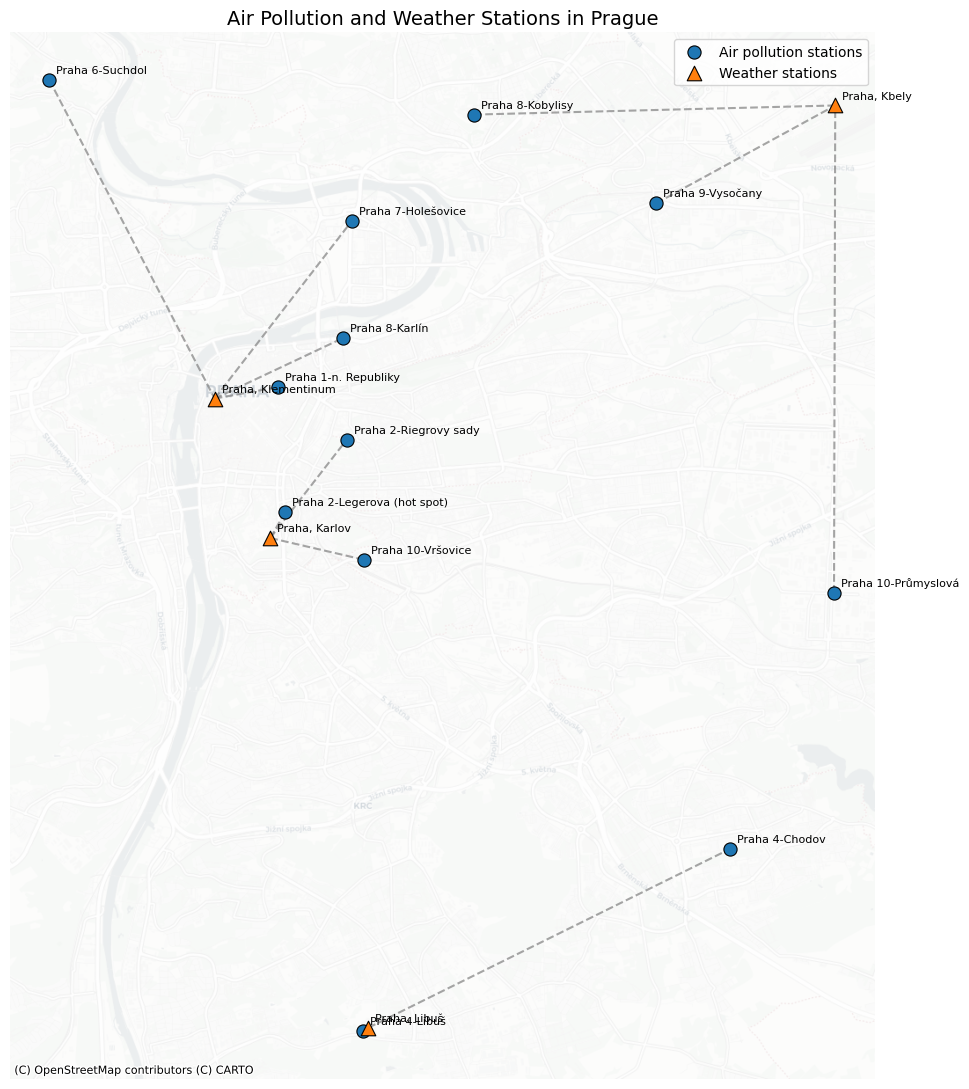

In [126]:

weather_id_col = "weather_station_name"
weather_lat_col = "weather_lat"
weather_lon_col = "weather_lon"

air_id_col = "air_station_name"
air_lat_col = "air_lat"
air_lon_col = "air_lon"

coord_cols = [weather_lat_col, weather_lon_col, air_lat_col, air_lon_col]
df[coord_cols] = df[coord_cols].apply(pd.to_numeric, errors="coerce")

weather_stations = (
    df[[weather_id_col, weather_lat_col, weather_lon_col]]
    .dropna()
    .drop_duplicates()
    .copy()
)

air_stations = (
    df[[air_id_col, air_lat_col, air_lon_col]]
    .dropna()
    .drop_duplicates()
    .copy()
)

pairs = (
    df[
        [
            air_id_col, air_lat_col, air_lon_col,
            weather_id_col, weather_lat_col, weather_lon_col
        ]
    ]
    .dropna()
    .drop_duplicates()
    .copy()
)

gdf_weather = gpd.GeoDataFrame(
    weather_stations,
    geometry=gpd.points_from_xy(
        weather_stations[weather_lon_col],
        weather_stations[weather_lat_col]
    ),
    crs="EPSG:4326"
)

gdf_air = gpd.GeoDataFrame(
    air_stations,
    geometry=gpd.points_from_xy(
        air_stations[air_lon_col],
        air_stations[air_lat_col]
    ),
    crs="EPSG:4326"
)

pair_lines = []
for _, row in pairs.iterrows():
    line = LineString([
        (row[air_lon_col], row[air_lat_col]),
        (row[weather_lon_col], row[weather_lat_col])
    ])
    pair_lines.append({
        "air_station": row[air_id_col],
        "weather_station": row[weather_id_col],
        "geometry": line
    })

gdf_pairs = gpd.GeoDataFrame(pair_lines, crs="EPSG:4326")

gdf_weather = gdf_weather.to_crs(epsg=3857)
gdf_air = gdf_air.to_crs(epsg=3857)
gdf_pairs = gdf_pairs.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(11, 11))

gdf_pairs.plot(
    ax=ax,
    linewidth=1.5,
    alpha=0.7,
    color="gray",
    linestyle="--",
    zorder=1
)

gdf_air.plot(
    ax=ax,
    markersize=90,
    marker="o",
    label="Air pollution stations",
    alpha=1.0,
    edgecolor="black",
    linewidth=0.8,
    zorder=3
)

gdf_weather.plot(
    ax=ax,
    markersize=110,
    marker="^",
    label="Weather stations",
    alpha=1.0,
    edgecolor="black",
    linewidth=0.8,
    zorder=4
)

for _, row in gdf_air.iterrows():
    ax.annotate(
        row[air_id_col],
        xy=(row.geometry.x, row.geometry.y),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
        zorder=5
    )

for _, row in gdf_weather.iterrows():
    ax.annotate(
        row[weather_id_col],
        xy=(row.geometry.x, row.geometry.y),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
        zorder=5
    )

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron,
    alpha=0.45   # smaller alpha = lighter / less visible background
)

ax.set_title("Air Pollution and Weather Stations in Prague", fontsize=14)
ax.set_axis_off()
ax.legend()

plt.tight_layout()
plt.show()

### Histograms of weather and air quality variables

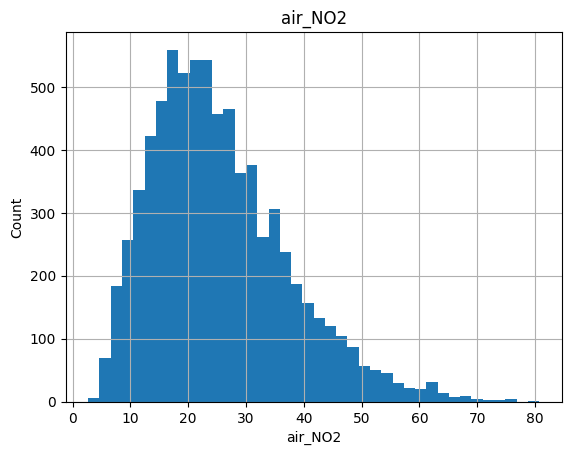

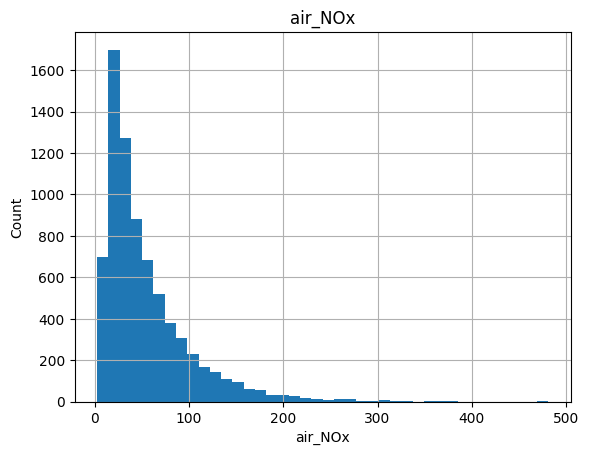

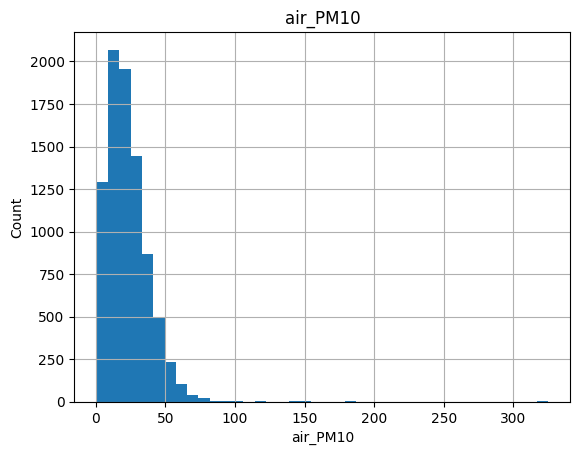

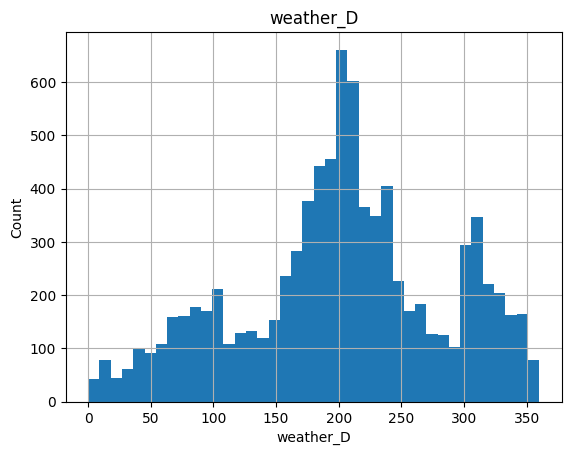

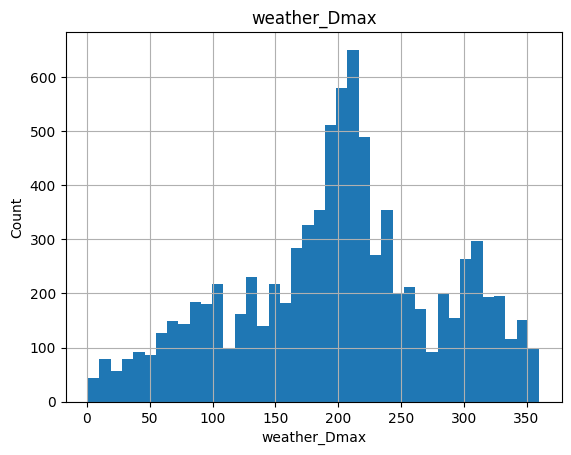

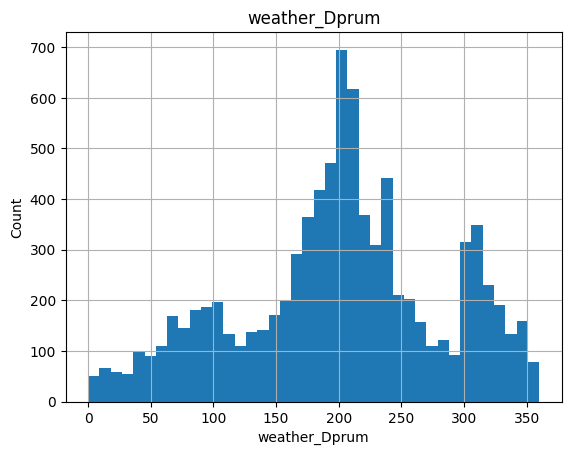

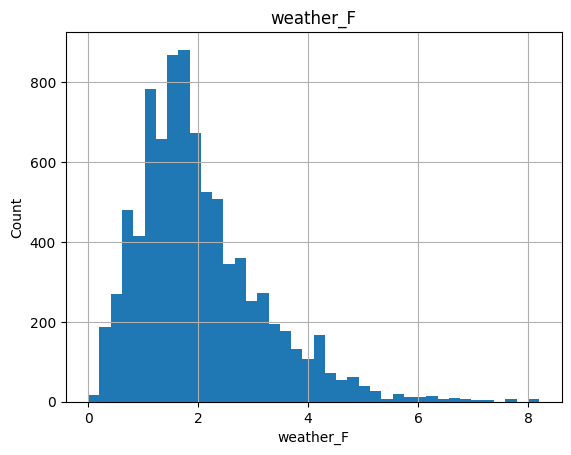

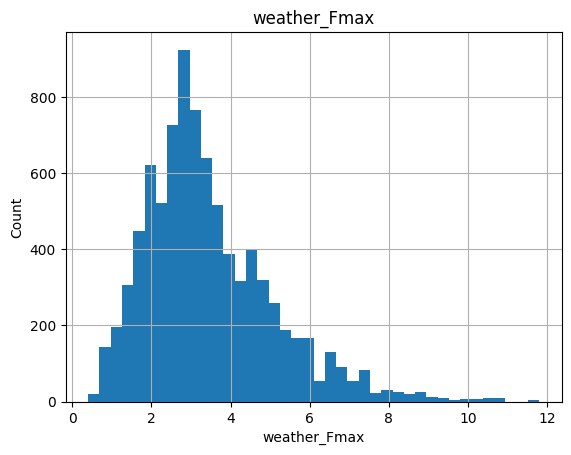

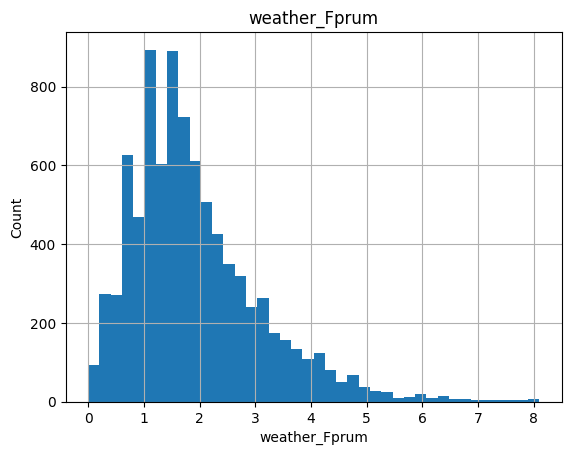

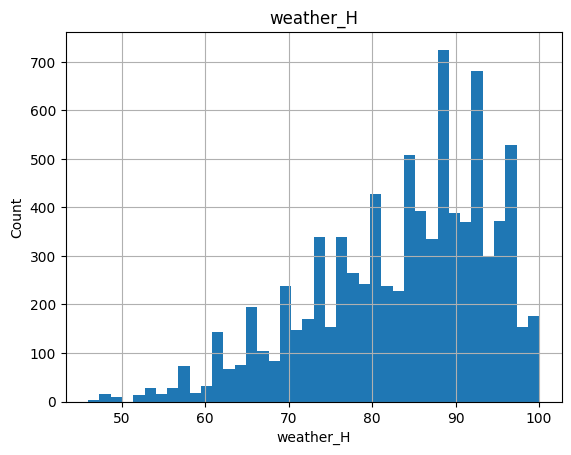

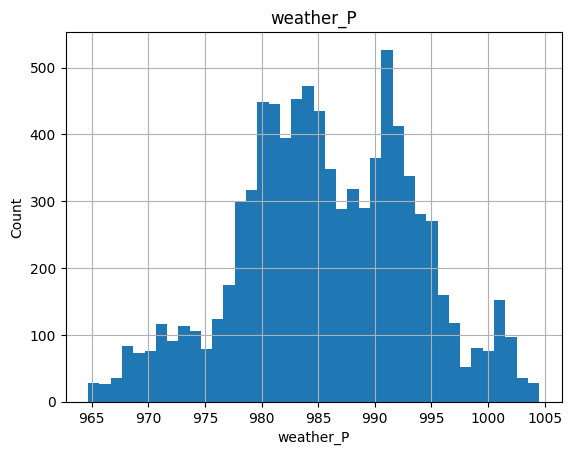

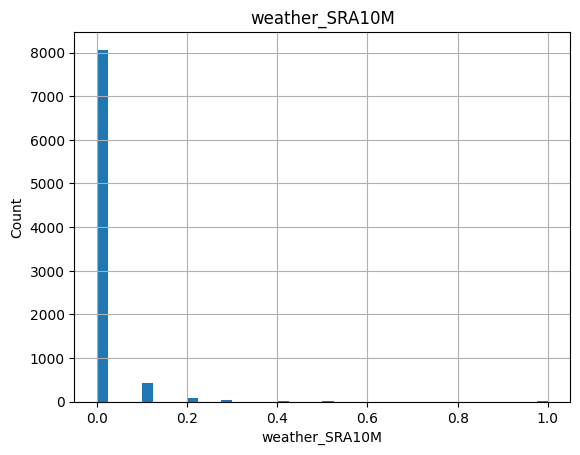

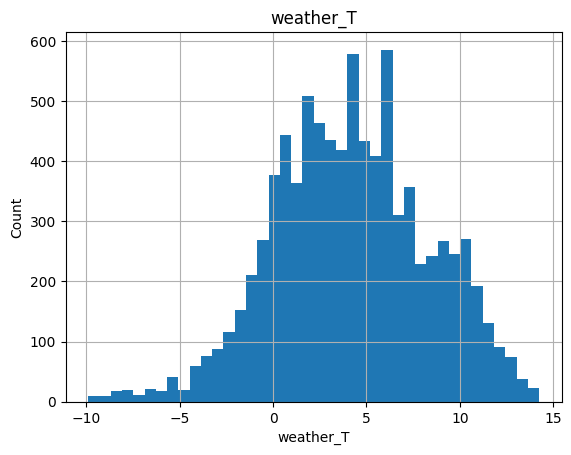

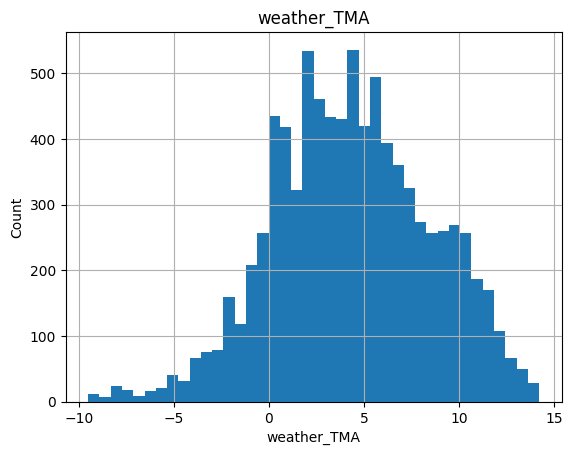

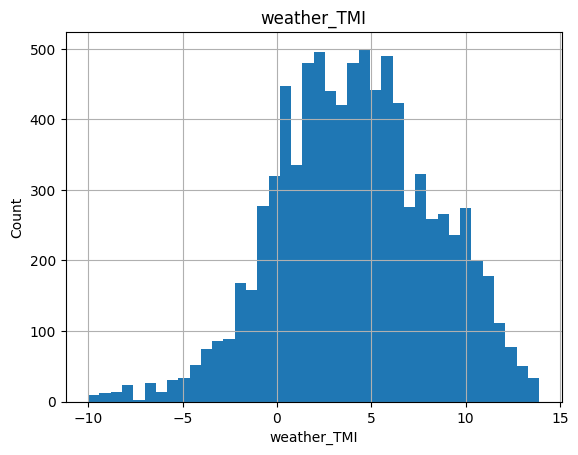

In [ ]:
for col in target_cols + weather_cols:
    plt.figure()
    df[col].hist(bins=40)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

### Time series of air quality variables

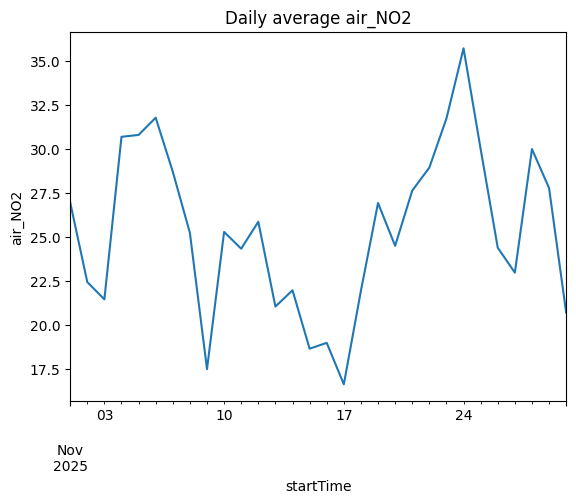

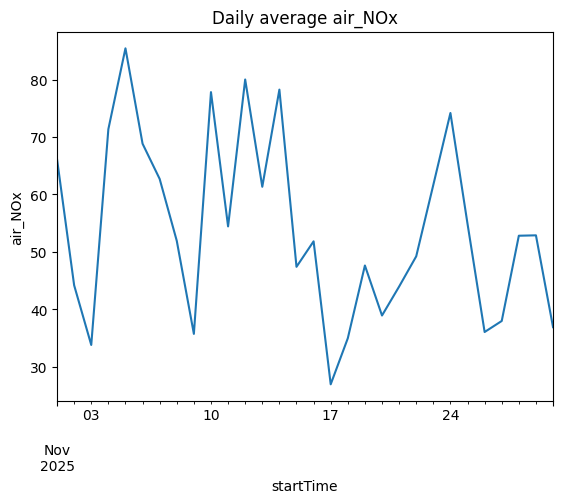

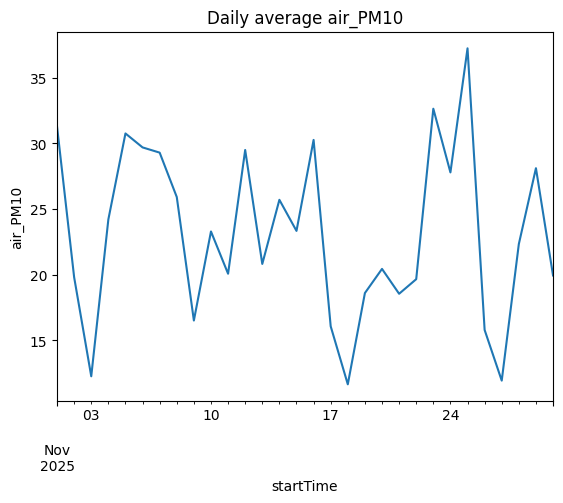

In [60]:
for col in target_cols:
    plt.figure()
    df.set_index("startTime")[col].resample("D").mean().plot()
    plt.title(f"Daily average {col}")
    plt.ylabel(col)
    plt.show()

### Boxplots of air_quality variables by station

<Figure size 1000x400 with 0 Axes>

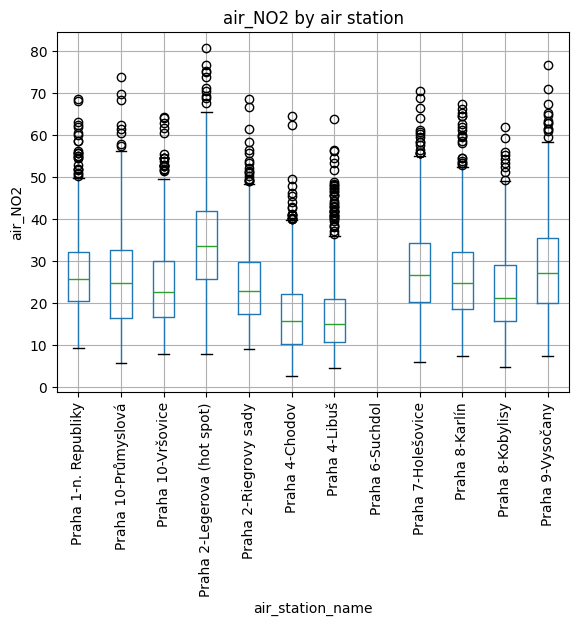

<Figure size 1000x400 with 0 Axes>

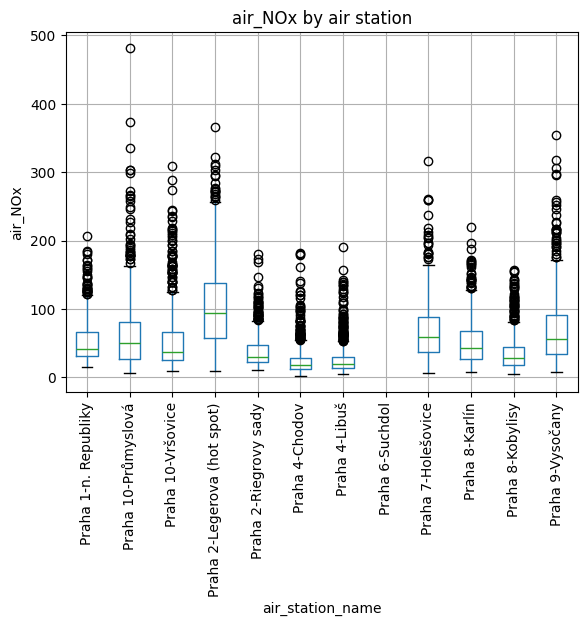

<Figure size 1000x400 with 0 Axes>

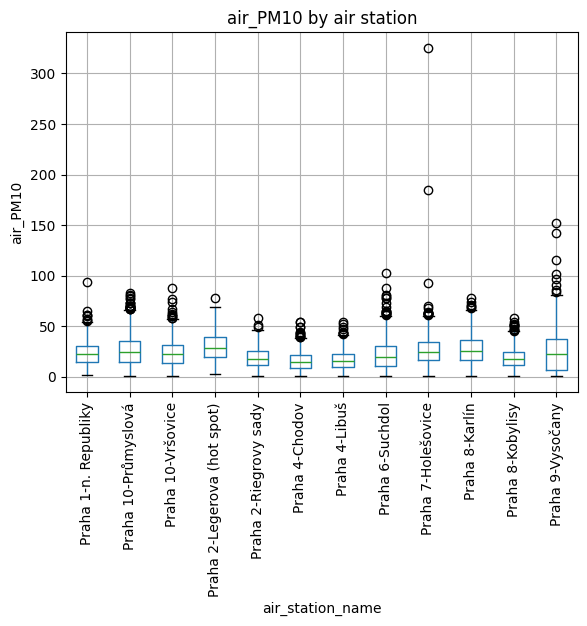

In [61]:
for col in target_cols:
    plt.figure(figsize=(10, 4))
    df.boxplot(column=col, by="air_station_name", rot=90)
    plt.title(f"{col} by air station")
    plt.suptitle("")
    plt.ylabel(col)
    plt.show()

### Scatter plots of weather vs air quality variables

<Figure size 640x480 with 0 Axes>

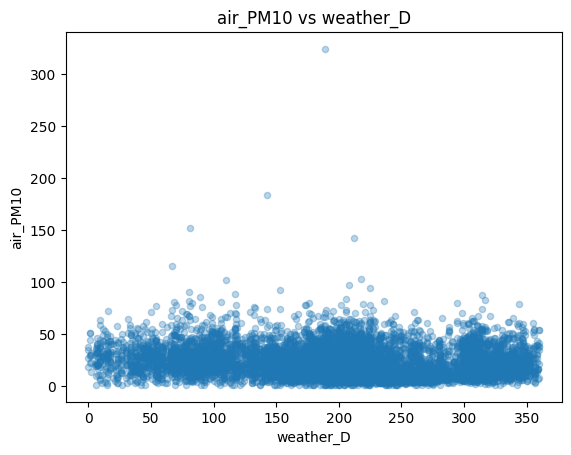

<Figure size 640x480 with 0 Axes>

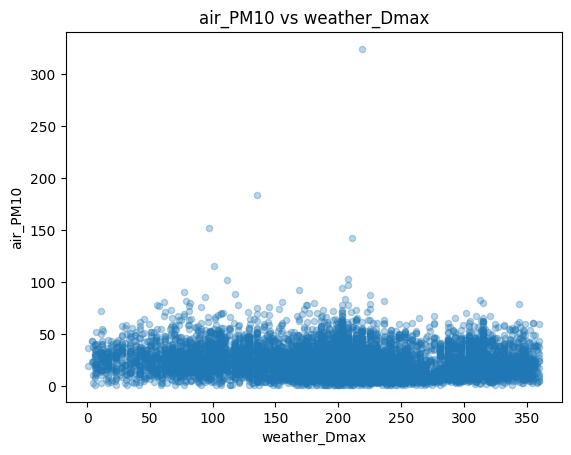

<Figure size 640x480 with 0 Axes>

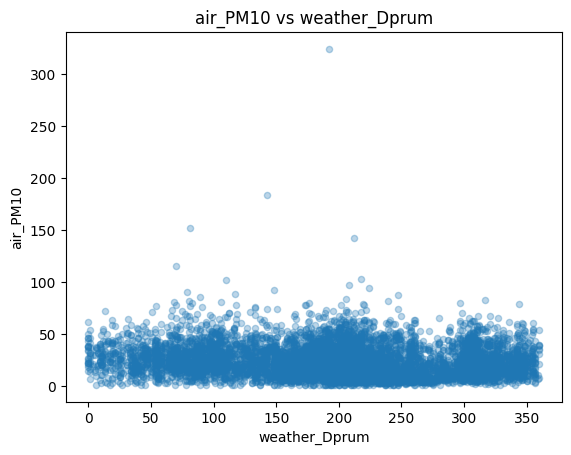

<Figure size 640x480 with 0 Axes>

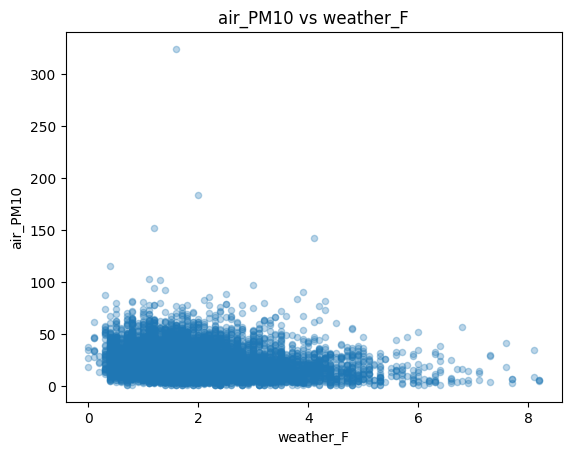

<Figure size 640x480 with 0 Axes>

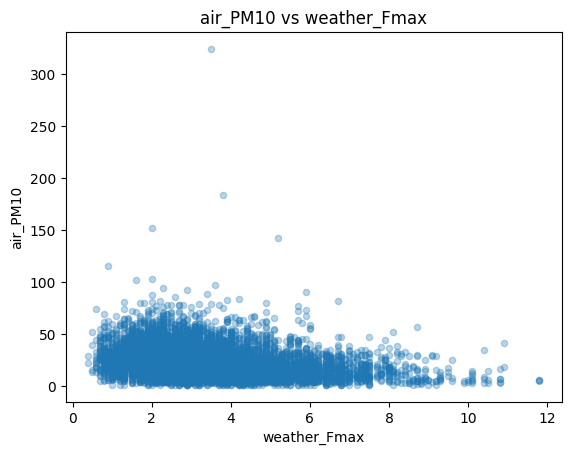

<Figure size 640x480 with 0 Axes>

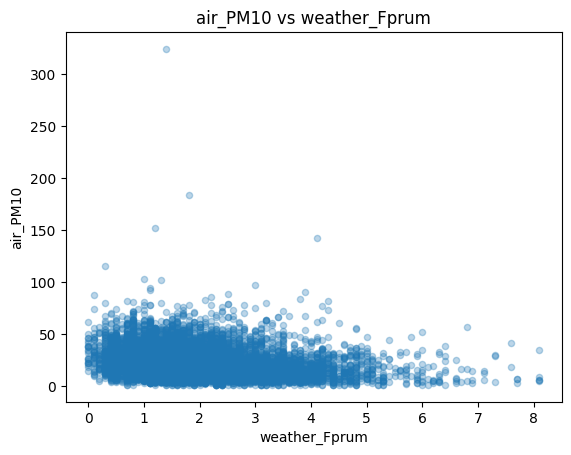

<Figure size 640x480 with 0 Axes>

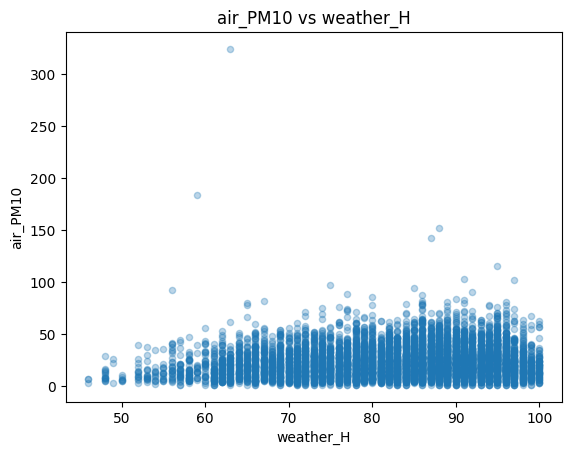

<Figure size 640x480 with 0 Axes>

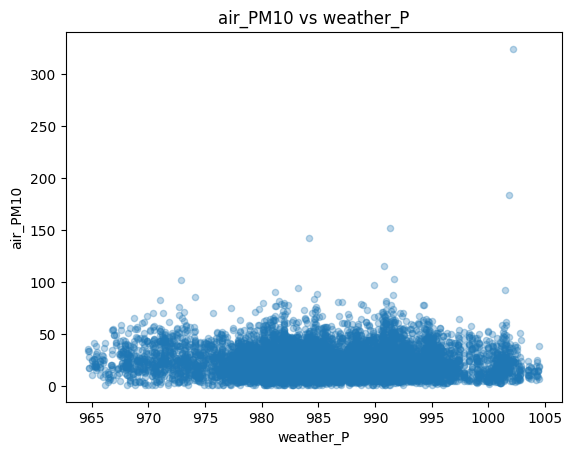

<Figure size 640x480 with 0 Axes>

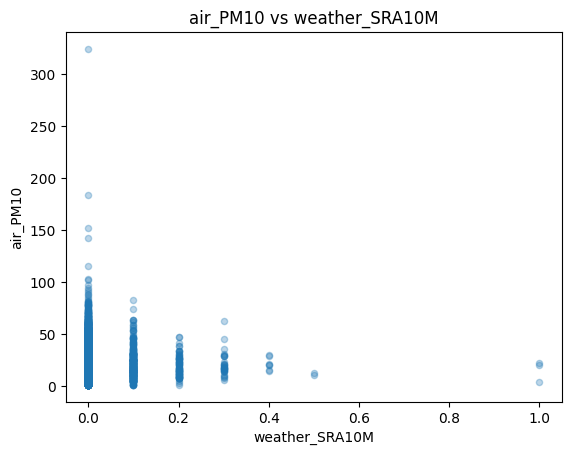

<Figure size 640x480 with 0 Axes>

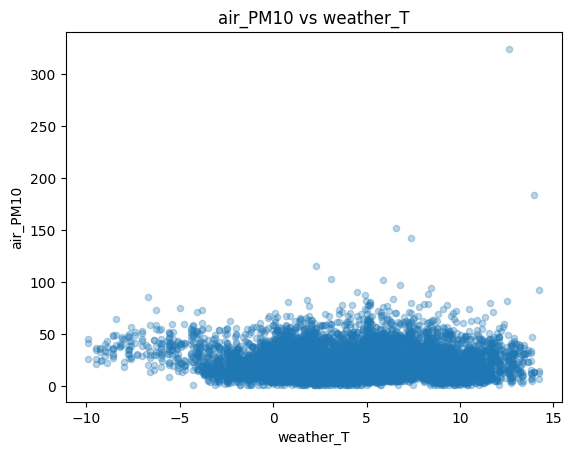

<Figure size 640x480 with 0 Axes>

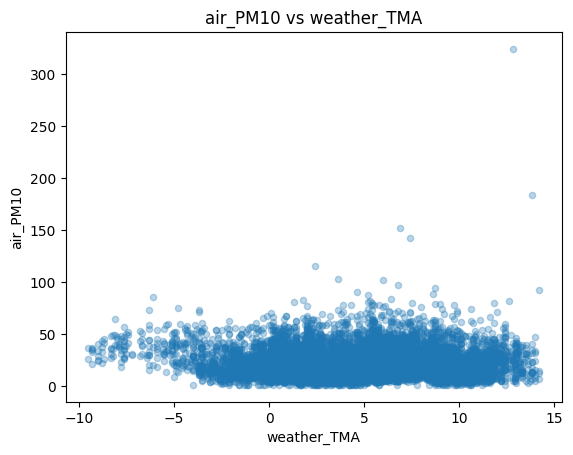

<Figure size 640x480 with 0 Axes>

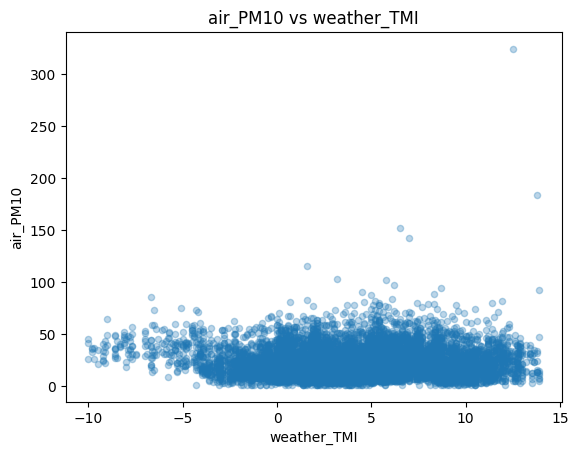

In [104]:
# Start with air_PM10
target = "air_PM10"

for col in weather_cols:
    plt.figure()
    df.plot.scatter(x=col, y=target, alpha=0.3)
    plt.title(f"{target} vs {col}")
    plt.show()

### Correlations

In [47]:
corr_cols = target_cols + weather_cols + spatial_cols

corr_matrix = df[corr_cols].corr()

corr_matrix[target_cols].sort_values("air_PM10", ascending=False)

,air_NO2,air_NOx,air_PM10
air_PM10,0.399279,0.525674,1.000000
air_NOx,0.738218,1.000000,0.525674
air_NO2,1.000000,0.738218,0.399279
weather_lat,0.232827,0.205906,0.165265
air_lat,0.242336,0.173682,0.116458
weather_H,-0.153139,0.042437,0.112637
weather_TMA,-0.053791,0.051249,0.006842
weather_TMI,-0.056345,0.045911,0.003306
weather_T,-0.059618,0.047002,0.002425
weather_P,0.131297,0.115847,-0.010066


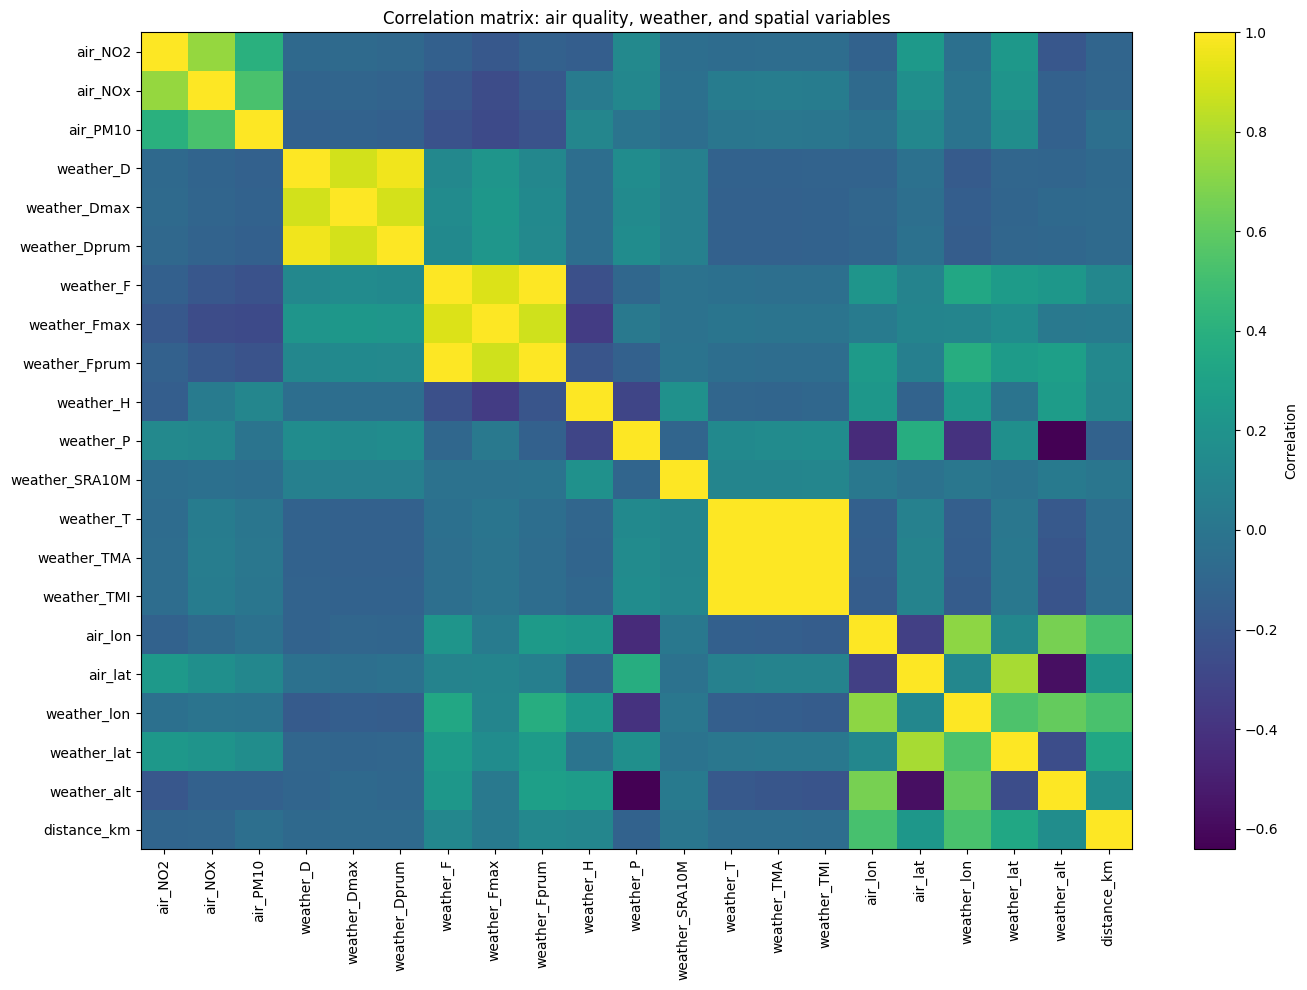

In [48]:
### Heatmap
plt.figure(figsize=(14, 10))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(corr_matrix.index)),
    corr_matrix.index
)

plt.title("Correlation matrix: air quality, weather, and spatial variables")
plt.tight_layout()
plt.show()

### Convert and create explanatory variables

In [116]:
# convert wind to vector
#wind_u > 0  means wind blows toward the east
#wind_u < 0  means wind blows toward the west
#wind_v > 0  means wind blows toward the north
#wind_v < 0  means wind blows toward the south

theta = np.deg2rad(df_merged["weather_D"])

# Wind vector showing where the wind is blowing TO
df["wind_u"] = -df["weather_F"] * np.sin(theta)
df["wind_v"] = -df["weather_F"] * np.cos(theta)


df["startTime"] = pd.to_datetime(df["startTime"])
df = df.sort_values(["air_station_name", "startTime"]).reset_index(drop=True)

meteo_vars = ["weather_F", "wind_u", "wind_v", "weather_T", "weather_H", "weather_P"]

for var in meteo_vars:
    df[f"{var}_lag1"] = df.groupby("air_station_name")[var].shift(1)

    df[f"{var}_mean3"] = (
        df.groupby("air_station_name")[var]
        .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
    )

    df[f"{var}_mean6"] = (
        df.groupby("air_station_name")[var]
        .transform(lambda x: x.shift(1).rolling(6, min_periods=1).mean())
    )

for window in [3, 6, 12, 24]:
    df[f"precip_sum{window}"] = (
        df.groupby("air_station_name")["weather_SRA10M"]
        .transform(lambda x: x.shift(1).rolling(window, min_periods=1).sum())
    )

df["weather_P_change6"] = (
    df["weather_P"] - df.groupby("air_station_name")["weather_P"].shift(6)
)

In [117]:
df 

,startTime,weather_station_name,air_station_name,air_NO2,air_NOx,air_PM10,weather_D,weather_Dmax,weather_Dprum,weather_F,...,weather_H_mean3,weather_H_mean6,weather_P_lag1,weather_P_mean3,weather_P_mean6,precip_sum3,precip_sum6,precip_sum12,precip_sum24,weather_P_change6
0,2025-11-01 00:00:00,"Praha, Klementinum",Praha 1-n. Republiky,42.1,158.6,45.4,119.0,129.0,133.0,0.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-11-01 01:00:00,"Praha, Klementinum",Praha 1-n. Republiky,36.0,136.0,52.3,200.0,197.0,205.0,1.0,...,82.000000,82.000000,995.1,995.100000,995.100000,0.0,0.0,0.0,0.0,NaN
2,2025-11-01 02:00:00,"Praha, Klementinum",Praha 1-n. Republiky,36.2,136.4,44.2,255.0,231.0,246.0,0.7,...,82.000000,82.000000,994.8,994.950000,994.950000,0.0,0.0,0.0,0.0,NaN
3,2025-11-01 03:00:00,"Praha, Klementinum",Praha 1-n. Republiky,28.3,79.0,47.9,216.0,169.0,216.0,1.4,...,82.666667,82.666667,995.4,995.100000,995.100000,0.0,0.0,0.0,0.0,NaN
4,2025-11-01 04:00:00,"Praha, Klementinum",Praha 1-n. Republiky,26.6,55.3,37.9,190.0,101.0,185.0,0.5,...,83.333333,83.000000,994.7,994.966667,995.000000,0.0,0.0,0.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8623,2025-11-30 19:00:00,"Praha, Kbely",Praha 9-Vysočany,29.6,59.5,5.1,53.0,59.0,53.0,1.3,...,97.666667,97.333333,981.2,981.066667,980.733333,0.0,0.0,0.0,0.0,1.2
8624,2025-11-30 20:00:00,"Praha, Kbely",Praha 9-Vysočany,29.3,62.4,28.0,69.0,67.0,69.0,1.5,...,97.666667,97.500000,981.5,981.266667,980.933333,0.0,0.0,0.0,0.0,1.5
8625,2025-11-30 21:00:00,"Praha, Kbely",Praha 9-Vysočany,29.3,70.6,37.3,9.0,5.0,9.0,0.8,...,98.000000,97.666667,981.8,981.500000,981.183333,0.0,0.0,0.0,0.0,1.5
8626,2025-11-30 22:00:00,"Praha, Kbely",Praha 9-Vysočany,27.0,45.3,12.5,346.0,353.0,346.0,0.9,...,98.333333,98.000000,982.1,981.800000,981.433333,0.0,0.0,0.0,0.0,1.6


In [125]:
df["weather_station_name"].unique()

<StringArray>
['Praha, Klementinum', 'Praha, Kbely', 'Praha, Karlov', 'Praha, Libuš']
Length: 4, dtype: str

## Baseline modeling
just a draft, the variables are not prepared

In [124]:
def run_rf_model(df, target, predictor_cols):
    df_model = df[[target, "startTime"] + predictor_cols].dropna(subset=[target]).copy()
    df_model = df_model.sort_values("startTime")

    split_index = int(len(df_model) * 0.8)

    train = df_model.iloc[:split_index].copy()
    test = df_model.iloc[split_index:].copy()

    X_train = train[predictor_cols]
    y_train = train[target]

    X_test = test[predictor_cols]
    y_test = test[target]

    model = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(
            n_estimators=300,
            random_state=42,
            min_samples_leaf=5,
            n_jobs=-1
        ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    metrics = {
        "target": target,
        "n_train": len(train),
        "n_test": len(test),
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2": r2_score(y_test, y_pred)
    }

    importance = pd.DataFrame({
        "target": target,
        "variable": predictor_cols,
        "importance": model.named_steps["model"].feature_importances_
    }).sort_values("importance", ascending=False)

    results = test[["startTime"]].copy()
    results["actual"] = y_test.values
    results["predicted"] = y_pred
    results["error"] = results["actual"] - results["predicted"]

    return model, metrics, importance, results

In [ ]:
models = {}
metrics_list = []
importance_list = []

for target in target_cols:
    model, metrics, importance, results = run_rf_model(df, target, predictor_cols)

    models[target] = model
    metrics_list.append(metrics)
    importance_list.append(importance)

metrics_table = pd.DataFrame(metrics_list)
importance_table = pd.concat(importance_list, ignore_index=True)

metrics_table

,target,n_train,n_test,MAE,RMSE,R2
0,air_NO2,5973,1494,6.213154,7.955723,0.389698
1,air_NOx,5972,1494,20.058760,28.191178,0.317148
2,air_PM10,6830,1708,9.905860,13.324939,0.065443


NameError: name 'target_cols' is not defined